# Feynman's ratchet

The well-known ratchet and pawl mechanism was famously discussed in Feynman's lectures on physics [1] as an illustration of statistical mechanics.

The system consists of a ratchet wheel and pawl enclosed in a box containing gas at temperature $T_2$. The axle of the ratchet extends into a second box with gas at temperature $T_1$, where a set of vanes is attached to it. Gas molecules collide with the vanes, attempting to rotate the axle in both directions; however, the pawl is designed to restrict motion only in one direction. Outside the boxes, a drum is mounted on the axle with a string wrapped around it, holding a small weight. Depending on the conditions, this mechanism may or may not perform net work by lifting the weight.

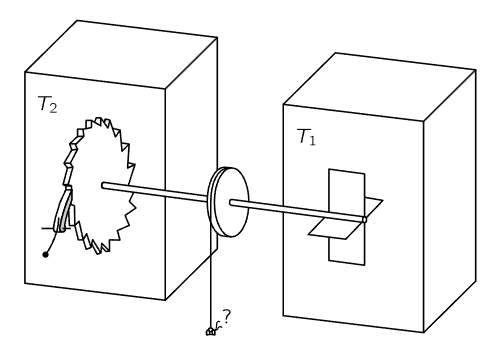

(Image source: [1])

*Summary on the Feynamn's result [1]:*
Gas molecules also collide with the pawl, causing it to bounce and randomly disengage from thee ratchet wheel. Consequently, the axle can slip backward--opposite to the direction intended by the pawl design.
When two reservoirs are at equal temperature ($T_1 = T_2$), these thermal jumps allow frequent backward slips. In the presence of a suspended weight, forward thermal pushes and backward slips do not merely balance out; the constant downward force of gravity causes the weight to gradually lower on average.
However, if the ratchet enclosure is cooled relative to the vanes ($T_1 > T_2$), thermal fluctuations of the pawl are significantly reduced. The pawl firmly suppresses backward motion, allowing the forward collisions on the vanes to dominate and produce net work by lifting the weight.

## Boxes with the same temperature $T_1 = T_2$

The potential of the ratchet could be described as a saw-tooth potential (periodic linear segments, one being steeper, to create the asymmetry caused by the ratchet and pawl mechanism). We will use the following function, where $x$-coordinate can be understood as distance measured along the ratchet wheel:

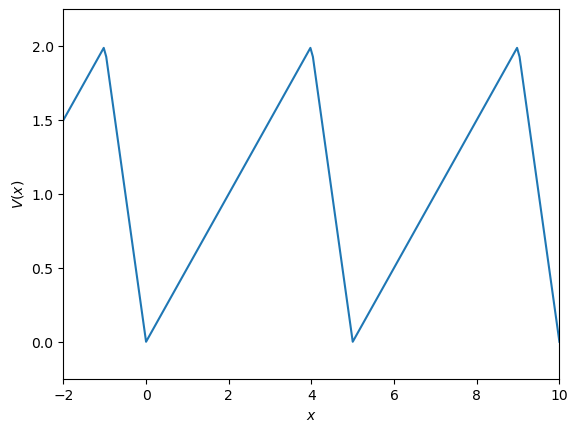

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x0 = 5
x1 = 4
a = 2

def U(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a*phase/x1, a-a*(phase-x1)/(x0-x1))

x = np.linspace(-5,10,250)
ux = np.empty_like(x)
for i in range(len(ux)):
    ux[i] = U(x[i])

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"$x$", ylabel=r"$V(x)$", xlim=[-2,10], ylim=[-0.25,2.25])
ax.plot(x, ux)

Using the package `LSolver`, we can easily get the solution to the corresponding Langevin equation:

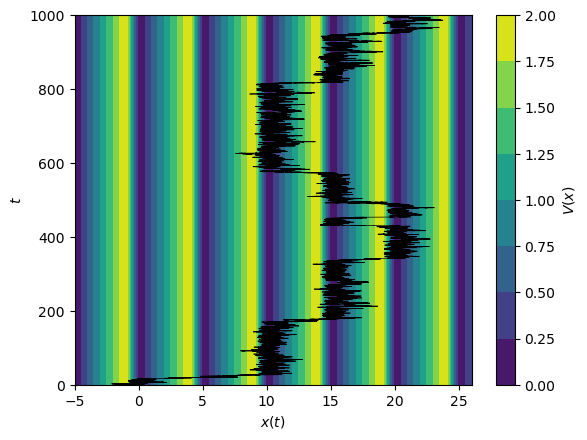

In [2]:
from LSolver import SimulationConfig, overdamped

def F(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return - np.where(cond, a/x1, - a/(x0-x1))

beta = 1.0
T = 1/beta
gma = 2.0

cfg = SimulationConfig(
    gamma = gma,
    Fx_func = lambda t,x,y: F(x),
    Tx_func = lambda t,x,y: T,
    t_max = 1000.0,
    dt = 0.001
)

fig, ax = plt.subplots(1,1)

[X, Y] = np.meshgrid(np.linspace(-5.0,26.0,150),np.linspace(0,1000,150))
Z = U(X)

cs = ax.contourf(X,Y,Z)

rng = np.random.default_rng(seed = 42)

data = overdamped(cfg, rng = rng)[0]

ax.set(xlabel = r"$x(t)$", ylabel = r"$t$")
ax.plot(data, cfg.t_array, color = "black", linewidth=0.5)
fig.colorbar(cs, label = r"$V(x)$")

Next step is to run some statistics over ensemble of systems with same initial conditions:

100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:30<00:00, 16.26it/s]


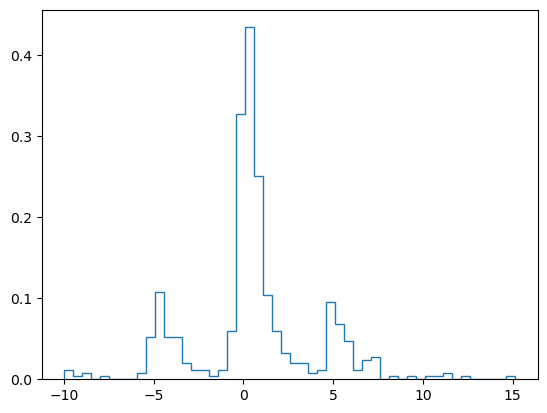

In [3]:
from tqdm import tqdm

N = 500
rng = np.random.default_rng(seed=2048)

cfg = SimulationConfig(
    gamma = gma,
    Fx_func = lambda t,x,y: F(x),
    Tx_func = lambda t,x,y: T,
    t_max = 40.0,
    dt = 0.005
)

data = np.empty(shape=(N,len(cfg.t_array)))

for m in tqdm(range(N)):
    data[m] = overdamped(cfg, rng=rng)[0]

fig, ax = plt.subplots(1,1)
counts, bins = np.histogram(data[:,-1],density = True, bins=50)
ax.stairs(counts, bins)

Because the potential is periodic, it is natural to restrict our analysis to a single period. Although an infinite ratchet would require infinite time and ensemble size to sample fully, a real ratchet wheel has a finite number of cogs. Insteed of simulating the entire macroscopic wheel, we can simulate just a single period using periodic boundary conditions (effectively treating the coordinate space as a circle--if the system crosses the boundary on the right, it re-enters on the left). This dramatically reduces simulation time while yielding accurate statistical results for steady-state properties.

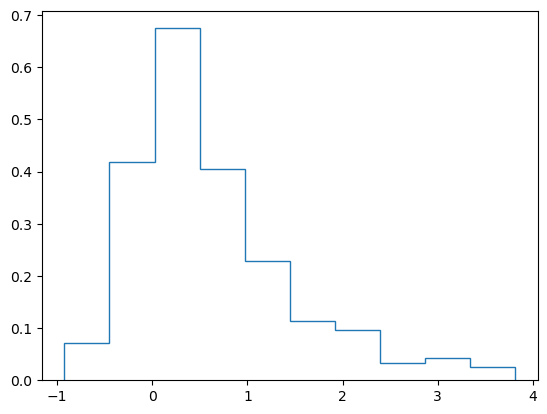

In [4]:
cond = (data <= 4) & (data >= -1)
data_new = np.where(cond, data, (data + 1) % 5 - 1)
fig, ax = plt.subplots(1,1)
counts, bins = np.histogram(data_new[:,-1],density = True, bins=10)
ax.stairs(counts, bins)

### Adding load

Up to this point, we have only considered the unloaded case. To add the suspended weight, we add a linear potential term, which increases the potential energy as the $x$-coordinate advances. Note that this load is applied to the potential in such manner that the pawl acts to prevent the weight from slipping backward down the slope.

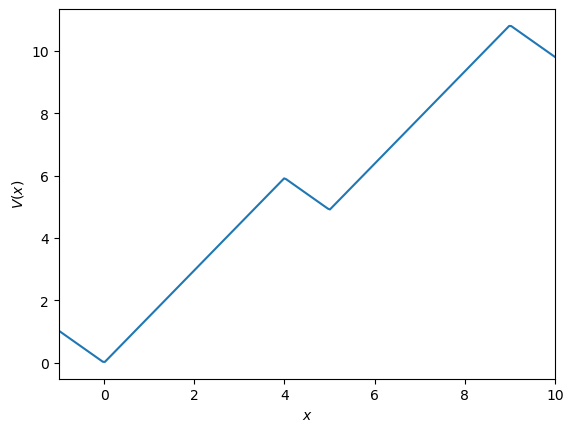

In [5]:
m = 0.1
g = 9.8

def U(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a*phase/x1 + m*g*x, a-a*(phase-x1)/(x0-x1) + m*g*x)

x = np.linspace(-1,10,250)
ux = np.empty_like(x)
for i in range(len(ux)):
    ux[i] = U(x[i])

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"$x$", ylabel=r"$V(x)$", xlim=[-1,10])
ax.plot(x, ux)

A single simulation illustrates that the ratchet axle is now much more prone to rotate in reverse against the pawl:

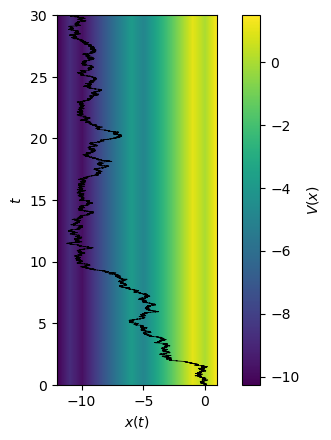

In [6]:
def F(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return - np.where(cond, a/x1 + m*g, - a/(x0-x1) + m*g)

beta = 1.0
T = 1/beta
gma = 2.0

cfg = SimulationConfig(
    gamma = gma,
    Fx_func = lambda t,x,y: F(x),
    Tx_func = lambda t,x,y: T,
    t_max = 30.0,
    dt = 0.001
)

fig, ax = plt.subplots(1,1)

[X, Y] = np.meshgrid(np.linspace(-12.0,1.0,150),np.linspace(0,30,150))
Z = U(X)

cs = ax.imshow(Z, interpolation="bilinear", origin="lower",
               extent=[-12.0,1.0,0.0,30.0])

rng = np.random.default_rng(seed = 42)

data = overdamped(cfg, rng = rng)[0]

ax.set(xlabel = r"$x(t)$", ylabel = r"$t$")
ax.plot(data, cfg.t_array, color = "black", linewidth=0.5)
fig.colorbar(cs, label = r"$V(x)$")

## What happens when we cool the pawl? ($T_1 < T_2$)

To account explicitely for the pawl, we introduce a second spatial coordinate $y$ corresponding to the deviation of the pawl from its equilibrium positiion:

$$V(x,y) = V_\text{ratchet} (x) + V_\text{load}(x) + V_\text{pawl} (y) + V_{coupling} (x,y).$$

Upon closer inspection, a separate static ratchet potential $V_\text{ratchet}(x)$ is no longer necessary, because the saw-tooth asymmetry is now naturally part of the coupling between the ratchet and the pawl. For now we will not consider any load, setting $V_\text{load}(x) = 0$.

The potential of the pawl itself is harmonic (pawl is pulled down to ratchet by spring)
$$V_\text{pawl} (y) = \frac{1}{2} ky^2,$$
where $y=0$ corresponds to the pawl resting in the innermost accessible part of the ratchet cogs (assumed to be the spring's equilibrium position), held by an elastic restoring force $k$.

The coupling potential can be modeled using a logistic curve:
$$V_\text{coupling} (x,y) = \frac{V_0}{1+\exp\left[(y-y_0(x))/\sigma\right]}.$$
Using this logistic function creates a smooth potential that divides the phase space into two main regions:
1. Below the teeth ($y < y_0(x)$): The potential is highest, representing the blocked state where the pawl engages the wheel.
2. Above the teeth ($y > y_0(x)$): The potential is lowest, reepresentinig the cleared state where the pawl is lifted.

Only in the immediate neighborhood of the boundary does a force act to push the pawl out of the ratchet wheel. This serves as a simple and effective model capturing the core mechanics of the ratchet and pawl system. While a fully rigorous treatment might require handling explicit boundary reflections when the system hits $y = y_0(x)$, that introduces significant numerical complexity, so this smooth potential model provides a robust compromise.

For simplicity, we choose the boundary curve $y_0(x)$ to match the saw-tooth profile $U(x)$ introduced earlier. Differentiating this potential yields the corresponding forces:
$$-\frac{\partial V}{\partial x} = -\frac{U_0}{4\sigma}\text{sech}^2\left(\frac{y-y_0(x)}{2\sigma}\right) y_0'(x),$$
$$-\frac{\partial V}{\partial y} = - ky + \frac{U_0}{4\sigma}\text{sech}^2\left(\frac{y-y_0(x)}{2\sigma}\right).$$

The potential profile in the $xy$ plane:

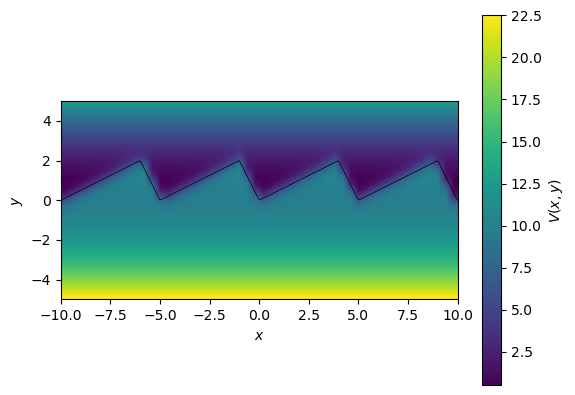

In [76]:
x0 = 5
x1 = 4
a = 2

beta = 0.5
T = 1/beta
gma = 2.0
k = 1.0

def y0(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a*phase/x1, a-a*(phase-x1)/(x0-x1))

def dy0(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a/x1, - a/(x0-x1))

u0 = 10.0
sigma = 0.2

def U0(x,y):
    return (u0/(4*sigma)) / (np.cosh((y-y0(x))/(2*sigma)))**2

fig, ax = plt.subplots(1,1)
ax.set(xlabel = r"$x$", ylabel = r"$y$")

[X, Y] = np.meshgrid(np.linspace(-10.0,10.0,50),np.linspace(-5,5,50))
Z = (1/2) * k * Y**2 + u0/(1+np.exp((Y-y0(X))/sigma))

cs = ax.imshow(Z, interpolation="bilinear", origin="lower",
         extent=[-10,10,-5,5])

x = np.linspace(-10,10,250)
y0x = y0(x)

ax.plot(x,y0x,color="black",linewidth=0.5)
fig.colorbar(cs, label = r"$V(x,y)$")

From the differentiation above, the force field can be plotted:

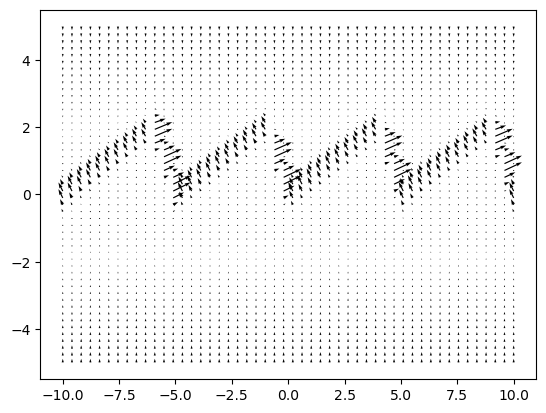

In [77]:
[X, Y] = np.meshgrid(np.linspace(-10.0,10.0,50),np.linspace(-5,5,50))
FX = - U0(X,Y)*dy0(X)
FY = - k * Y + U0(X,Y)

fig, ax = plt.subplots(1,1)

cs = ax.quiver(X, Y, FX, FY, units="width", scale = 1/0.0015)

Now we can incorporate the cooling of the pawl. The system of Langevin equations will now have the different temperatures for $x$-component fluctuations and $y$-component fluctuations. Specifically, the $x$-component corresponds to the ratchet axle and vanes (driven by gas collisions at temperature $T_1$), while the $y$-component corresponds to the pawl (at temperature $T_2$):
$$\dot x = \frac{F_x}{\gamma} + \sqrt{\frac{2 k_B T_1}{\gamma}}\xi_t,$$
$$\dot y = \frac{F_y}{\gamma} + \sqrt{\frac{2 k_B T_2}{\gamma}}\xi_t.$$
Using `LSolver`, the equations could be easily solved, demonstrating how cooling the pawl restores its ability to block reverse rotation:

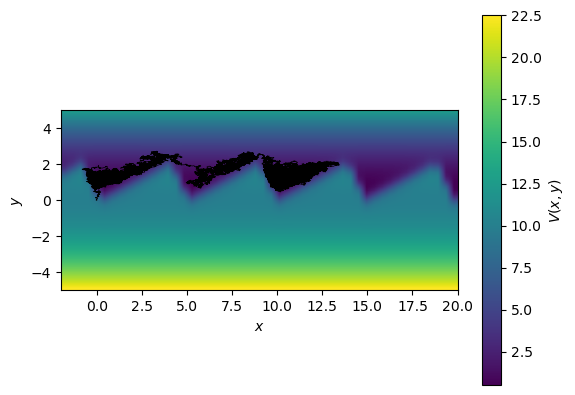

In [78]:
from LSolver import SimulationConfig, overdamped

cfg = SimulationConfig(
    gamma = gma,
    Fx_func = lambda t,x,y: - U0(x,y)*dy0(x),
    Tx_func = lambda t,x,y: T,
    Fy_func = lambda t,x,y: - k * y + U0(x,y),
    Ty_func = lambda t,x,y: 0.2*T,
    t_max = 100.0,
    dt = 0.001
)

fig, ax = plt.subplots(1,1)

[X, Y] = np.meshgrid(np.linspace(-2.0,20.0,50),np.linspace(-5,5,50))
Z = (1/2) * k * Y**2 + u0/(1+np.exp((Y-y0(X))/sigma))

cs = ax.imshow(Z, interpolation="bilinear", origin="lower",
         extent=[-2,20,-5,5])

rng = np.random.default_rng(seed = 42)

data = overdamped(cfg, rng = rng)

ax.set(xlabel = r"$x$", ylabel = r"$y$")
ax.plot(data[0], data[1], color = "black", linewidth=0.5)
fig.colorbar(cs, label = r"$V(x,y)$")

### Adding the load

Only modification needed to incorporate the load is to include the linear potential term much like before:
$$V_\text{load}(x) = mgx.$$
Setting up the conditions so that the system successfully pulls up the load requires a bit of parameter fine-tunning and sufficiently small load mass, but as demonstrated below, it works in principle. During this tuning process, I found that the most critical factors are the height of the coupling potential $V_0$–which effectively raises the barrier the pawl must overcome to permit reverse rotation–and indeed the temperature difference between the two components. (Note, however, that if $T_2 \ll T_1$ is taken to extreme, the pawl fluctuations become entirely negligible, which breaks the mechanism's thermal interplay!)

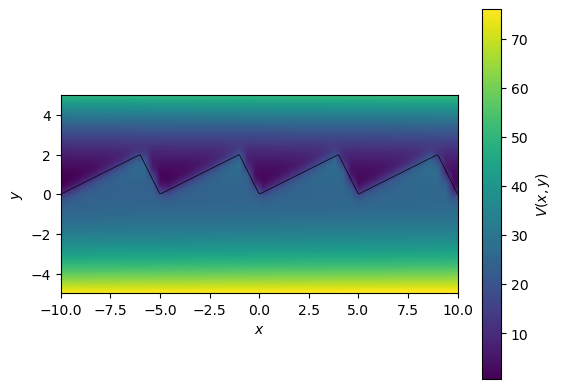

In [144]:
x0 = 5
x1 = 4
a = 2

T = 10
beta = 1/T
gma = 1.0
k = 4.0
m = 0.01
g = 9.8

def y0(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a*phase/x1, a-a*(phase-x1)/(x0-x1))

def dy0(x):
    phase = x % x0
    cond = (phase >= 0) & (phase <= x1)
    return np.where(cond, a/x1, - a/(x0-x1))

u0 = 25.0
sigma = 0.2

def U0(x,y):
    return (u0/(4*sigma)) / (np.cosh((y-y0(x))/(2*sigma)))**2

fig, ax = plt.subplots(1,1)
ax.set(xlabel = r"$x$", ylabel = r"$y$")

[X, Y] = np.meshgrid(np.linspace(-10.0,10.0,50),np.linspace(-5,5,50))
Z =  m * g * X + (1/2) * k * Y**2 + u0/(1+np.exp((Y-y0(X))/sigma))

cs = ax.imshow(Z, interpolation="bilinear", origin="lower",
         extent=[-10,10,-5,5])

x = np.linspace(-10,10,250)
y0x = y0(x)

ax.plot(x,y0x,color="black",linewidth=0.5)
fig.colorbar(cs, label = r"$V(x,y)$")

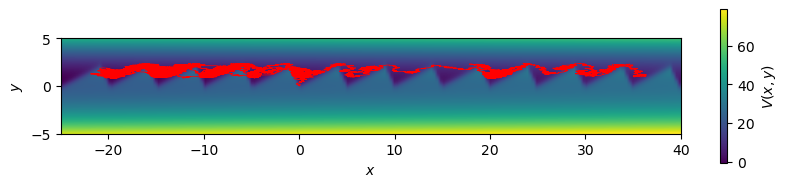

In [158]:
from LSolver import SimulationConfig, overdamped

cfg = SimulationConfig(
    gamma = gma,
    Fx_func = lambda t,x,y: - m * g - U0(x,y)*dy0(x),
    Tx_func = lambda t,x,y: T,
    Fy_func = lambda t,x,y: - k * y + U0(x,y),
    Ty_func = lambda t,x,y: 0.01*T,
    t_max = 25.0,
    dt = 0.001
)

fig, ax = plt.subplots(1,1,figsize=(10,2))

[X, Y] = np.meshgrid(np.linspace(-25.0,40.0,200),np.linspace(-5,5,50))
Z = m * g * X + (1/2) * k * Y**2 + u0/(1+np.exp((Y-y0(X))/sigma))

cs = ax.imshow(Z, interpolation="bilinear", origin="lower",
         extent=[-25,40,-5,5])

rng = np.random.default_rng(seed = 42)

data = overdamped(cfg, rng = rng)

ax.set(xlabel = r"$x$", ylabel = r"$y$")
ax.plot(data[0], data[1], color = "red", linewidth=0.5)
fig.colorbar(cs, label = r"$V(x,y)$")

## References

[1] Feynman, R. P., Leighton, R. B., & Sands, M. (2015). *The Feynman Lectures on Physics, Vol. I: The New Millennium Edition: Mainly Mechanics, Radiation, and Heat.* Basic Books.